# Manual Review Viewer for Segmentation Explainability

Use this notebook after the automatic failure taxonomy. You choose one or more trained models and a list of image filenames. The notebook displays the original image, ground truth, prediction, crack probability, TP/FN/FP overlap, and raw non-crack defect mask.

This is a semi-automatic review workflow: the model generates measurable evidence, and you manually confirm the final failure label.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from IPython.display import display, Markdown
from fastai.vision.all import imagenet_stats

def find_project_root(start: Path = Path.cwd()) -> Path:
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / 'baseline_models_scripts').exists() and (path / 'TACK_Tunnel_Data').exists():
            return path
    raise FileNotFoundError('Could not find CSCI5527-final project root')

PROJECT_ROOT = find_project_root()
RUNS_DIR = PROJECT_ROOT / 'baseline_models_scripts' / 'runs'
MODELS_DIR = RUNS_DIR / 'models'
OUTPUT_DIR = PROJECT_ROOT / 'analysis' / 'explainability_suite' / 'outputs'
REVIEW_OUTPUT_DIR = OUTPUT_DIR / 'manual_review_panels'
REVIEW_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(str(PROJECT_ROOT))
sys.path.append(str(PROJECT_ROOT / 'baseline_models_scripts'))

from train_ttd import build_model, baseline_model_pipeline, EXPERIMENTS

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
DEVICE


device(type='cuda', index=0)

## 1. Choose Model(s) and Images

Edit `MODEL_NAMES` and `REVIEW_IMAGE_NAMES`. The filenames should match the image files, such as `TB_Camera4_001493_I.png`.

`DECISION_THRESHOLD` controls the crack probability cutoff. Keep `0.50` for the original model behavior, or change it if you want to review a threshold-tuned prediction.


In [2]:
MODEL_NAMES = [
#     'Unet-efficientnet-b0-imagenet_Single-TB',
    'Unet-resnet34-imagenet_Single-TB',
]

REVIEW_IMAGE_NAMES = [
    'TB_Camera4_001493_I.png',
    'TB_Camera4_000034_L.png',
    'TB_Camera5_000894_E.png',
    'TB_Camera7_000012_E.png',
    'TB_Camera9_001004_A.png',
    'TB_Camera7_000389_H.png',
    'TB_Camera5_000894_B.png',
    'TB_Camera6_000020_H.png',
    'TB_Camera8_001399_F.png',
    'TB_Camera4_000334_N.png',
]

DECISION_THRESHOLD = 0.50
IMG_SIZE = 512

RAW_MASK_VALUES = {
    'crack': 40,
    'water_or_noncrack_defect': 160,
    'leaching_or_noncrack_defect': 200,
}

MODEL_NAMES, REVIEW_IMAGE_NAMES[:3], DECISION_THRESHOLD


(['Unet-resnet34-imagenet_Single-TB'],
 ['TB_Camera4_001493_I.png',
  'TB_Camera4_000034_L.png',
  'TB_Camera5_000894_E.png'],
 0.5)

## 2. Helpers


In [3]:
ARCH_OPTIONS = [
    'DeepLabV3Plus',
    'DeepLabV3',
    'UnetPlusPlus',
    'Segformer',
    'Unet',
    'FPN',
    'PSPNet',
    'Linknet',
    'PAN',
    'MAnet',
]


def parse_model_name(model_name):
    left, setting = model_name.split('_', 1)
    for arch in sorted(ARCH_OPTIONS, key=len, reverse=True):
        prefix = f'{arch}-'
        if left.startswith(prefix):
            rest = left[len(prefix):]
            parts = rest.split('-')
            encoder_weights = parts[-1]
            encoder_name = '-'.join(parts[:-1])
            return {
                'arch': arch,
                'encoder': encoder_name,
                'weights': encoder_weights,
                'setting': setting,
            }
    raise ValueError(f'Could not parse model name: {model_name}')


def original_mask_path_from_image_path(image_path):
    image_path = Path(image_path)
    img_name = image_path.stem
    parts = img_name.rsplit('_', 1)
    if len(parts) == 2:
        mask_name = f'{parts[0]}_fuse_{parts[1]}_1band.png'
    else:
        mask_name = f'{img_name}.png'
    return PROJECT_ROOT / 'TACK_Tunnel_Data' / '3_mask' / mask_name


def resize_nearest(arr, shape):
    if arr.shape == shape:
        return arr
    return cv2.resize(arr.astype(np.uint8), (shape[1], shape[0]), interpolation=cv2.INTER_NEAREST)


def prepare_review_data(setting):
    _, _, test_dl, custom_stats, df_test_ready = baseline_model_pipeline(
        base_dir=PROJECT_ROOT,
        dict_files=EXPERIMENTS[setting],
        bs=4,
        img_size=IMG_SIZE,
    )
    df_test_ready = df_test_ready.copy().reset_index(drop=True)
    df_test_ready['image_name'] = df_test_ready['image_abs_path'].apply(lambda p: Path(p).name)
    df_test_ready['raw_mask_path'] = df_test_ready['image_abs_path'].apply(original_mask_path_from_image_path)
    return test_dl, custom_stats, df_test_ready


def load_model(model_name):
    cfg = parse_model_name(model_name)
    ckpt_path = MODELS_DIR / f'{model_name}.pth'
    if not ckpt_path.exists():
        raise FileNotFoundError(ckpt_path)
    model = build_model(cfg['arch'], cfg['encoder'], cfg['weights'], classes=2)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.to(DEVICE).eval()
    return model, cfg


def denorm_image(img_tensor, custom_stats=None):
    stats = custom_stats if custom_stats else imagenet_stats
    mean = torch.tensor(stats[0], device='cpu').view(3, 1, 1)
    std = torch.tensor(stats[1], device='cpu').view(3, 1, 1)
    arr = (img_tensor.detach().cpu() * std + mean).permute(1, 2, 0).numpy()
    return np.clip(arr, 0, 1)


def load_raw_mask(row, target_shape):
    raw_path = Path(row['raw_mask_path'])
    if not raw_path.exists():
        return np.zeros(target_shape, dtype=np.uint8)
    raw = np.array(Image.open(raw_path))
    return resize_nearest(raw, target_shape)


def get_sample_from_test_dl(image_name, df_test_ready, test_dl, custom_stats=None):
    matches = df_test_ready.index[df_test_ready['image_name'].eq(image_name)].tolist()
    if not matches:
        raise ValueError(f'{image_name} not found in this setting test split.')
    wanted = int(matches[0])
    current = 0
    for images, masks in test_dl:
        if current + images.shape[0] > wanted:
            i = wanted - current
            row = df_test_ready.iloc[wanted]
            image_tensor = images[i]
            target = masks[i].squeeze().cpu().numpy().astype(np.uint8)
            raw_mask = load_raw_mask(row, target.shape)
            image_np = denorm_image(image_tensor, custom_stats)
            return row, image_tensor, image_np, target, raw_mask
        current += images.shape[0]
    raise IndexError(wanted)


def predict_tensor(model, image_tensor, threshold=0.50):
    x = image_tensor.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(x)
        prob = torch.softmax(logits, dim=1)[0, 1].detach().cpu().numpy()
    pred = (prob >= threshold).astype(np.uint8)
    return prob, pred


def compute_metrics(pred, target):
    pred_bool = pred.astype(bool)
    target_bool = target.astype(bool)
    tp = int((pred_bool & target_bool).sum())
    fp = int((pred_bool & ~target_bool).sum())
    fn = int((~pred_bool & target_bool).sum())
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    return {
        'tp_pixels': tp,
        'fp_pixels': fp,
        'fn_pixels': fn,
        'iou': iou,
        'f1': f1,
        'precision': precision,
        'recall': recall,
    }


def make_error_rgb(pred, target):
    pred = pred.astype(bool)
    target = target.astype(bool)
    rgb = np.zeros((*target.shape, 3), dtype=float)
    rgb[pred & target] = [0, 1, 0]
    rgb[(~pred) & target] = [1, 0, 0]
    rgb[pred & (~target)] = [1, 1, 0]
    return rgb


def safe_name(text):
    return ''.join(ch if ch.isalnum() or ch in {'-', '_'} else '_' for ch in str(text))


## 3. Review Panel Function

The overlap panel uses green = TP, red = FN, yellow = FP.


In [4]:
def make_review_panel(model_name, model, row, image_tensor, image_np, target, raw_mask, threshold=0.50, save=True, show=True):
    prob, pred = predict_tensor(model, image_tensor, threshold=threshold)
    metrics = compute_metrics(pred, target)

    other_defect = np.isin(
        raw_mask,
        [RAW_MASK_VALUES['water_or_noncrack_defect'], RAW_MASK_VALUES['leaching_or_noncrack_defect']],
    )
    error_rgb = make_error_rgb(pred, target)

    title = (
        f"{row['image_name']} | {model_name} | threshold={threshold:.2f} | "
        f"IoU={metrics['iou']:.3f}, F1={metrics['f1']:.3f}, "
        f"P={metrics['precision']:.3f}, R={metrics['recall']:.3f}, "
        f"FP={metrics['fp_pixels']}, FN={metrics['fn_pixels']}"
    )

    fig, ax = plt.subplots(1, 6, figsize=(24, 4))
    fig.suptitle(title, fontsize=12)
    ax[0].imshow(image_np); ax[0].set_title('Image')
    ax[1].imshow(target, cmap='gray'); ax[1].set_title('Ground truth')
    ax[2].imshow(pred, cmap='gray'); ax[2].set_title('Prediction')
    ax[3].imshow(error_rgb); ax[3].set_title('TP green / FN red / FP yellow')
    ax[4].imshow(image_np); ax[4].imshow(prob, cmap='jet', alpha=0.45); ax[4].set_title('Crack probability')
    ax[5].imshow(image_np); ax[5].imshow(other_defect, cmap='cool', alpha=0.45); ax[5].set_title('Other raw mask')
    for a in ax:
        a.axis('off')
    plt.tight_layout()

    out_path = None
    if save:
        model_dir = REVIEW_OUTPUT_DIR / safe_name(model_name)
        model_dir.mkdir(parents=True, exist_ok=True)
        out_path = model_dir / f"{safe_name(row['image_name'])}_thr{str(threshold).replace('.', 'p')}.png"
        fig.savefig(out_path, dpi=180, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)

    return {
        'model_name': model_name,
        'image_name': row['image_name'],
        'image_abs_path': row['image_abs_path'],
        'threshold': threshold,
        'gt_pixels': int(target.astype(bool).sum()),
        'pred_pixels': int(pred.astype(bool).sum()),
        **metrics,
        'panel_path': str(out_path) if out_path else '',
        'human_failure_type': '',
        'notes': '',
    }


## 4. Run Review

This cell creates one panel per selected image and model. It also saves a CSV that you can fill with human labels and notes.


## Reviewing `Unet-resnet34-imagenet_Single-TB` on `Single-TB`

Loading CSV metadata...
Sanitizing training and validation masks...


Sanitizing Masks: 100%|██████████| 424/424 [00:00<00:00, 1100.04it/s]


Sanitizing test masks...


Sanitizing Masks: 100%|██████████| 48/48 [00:00<00:00, 835.65it/s]


Generating Dataloaders...

Pipeline Ready:
 - Training batches: 82
 - Validation batches: 24
 - Testing batches: 12


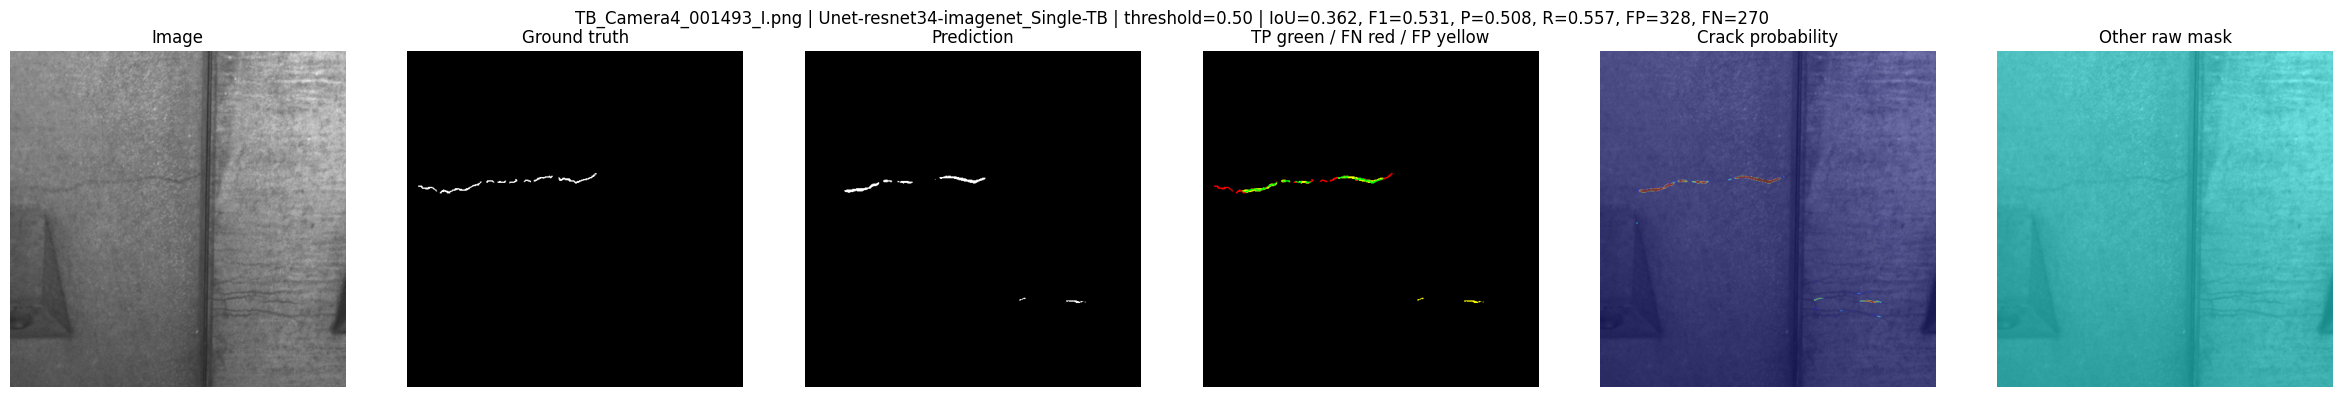

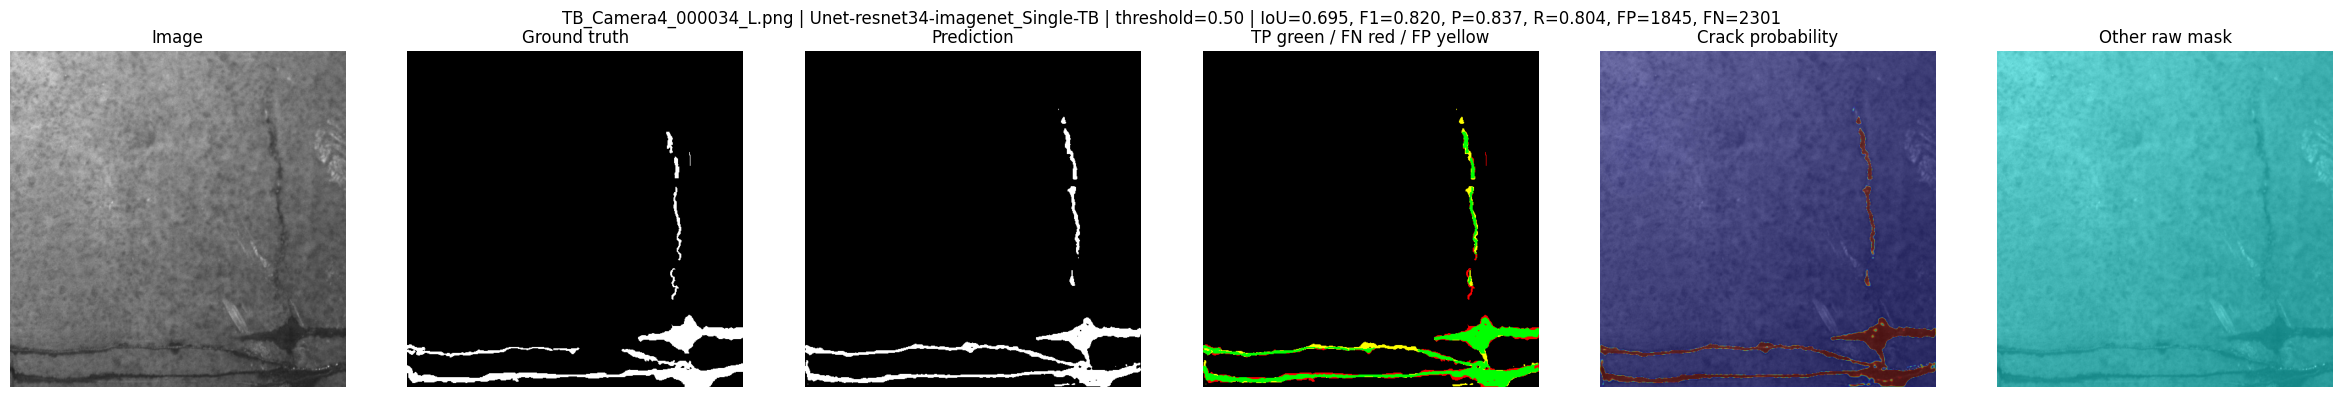

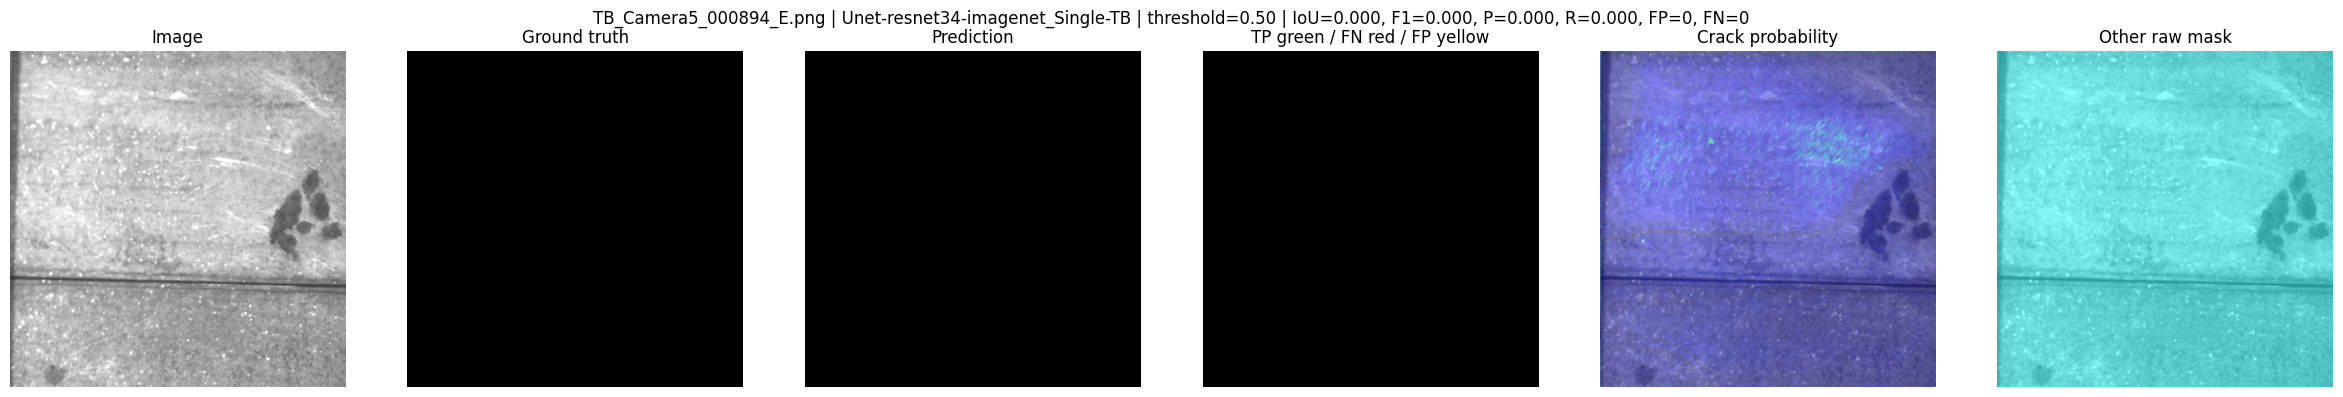

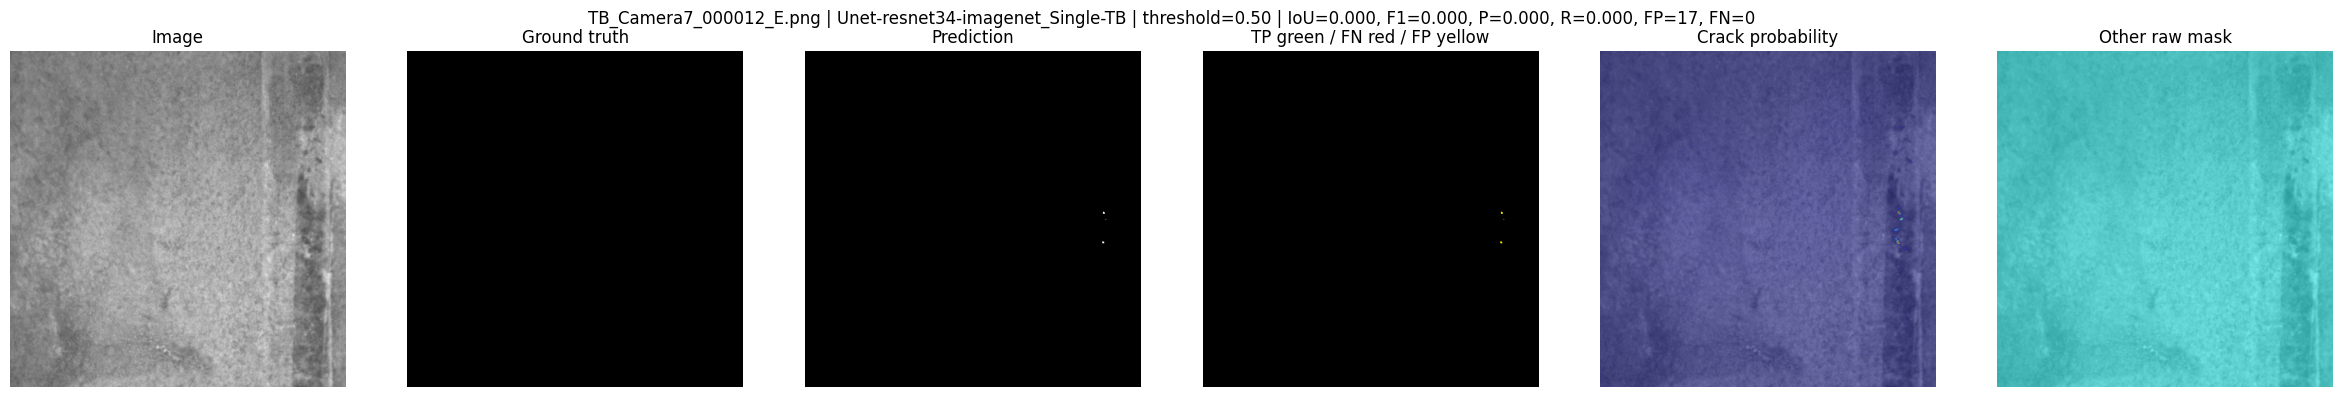

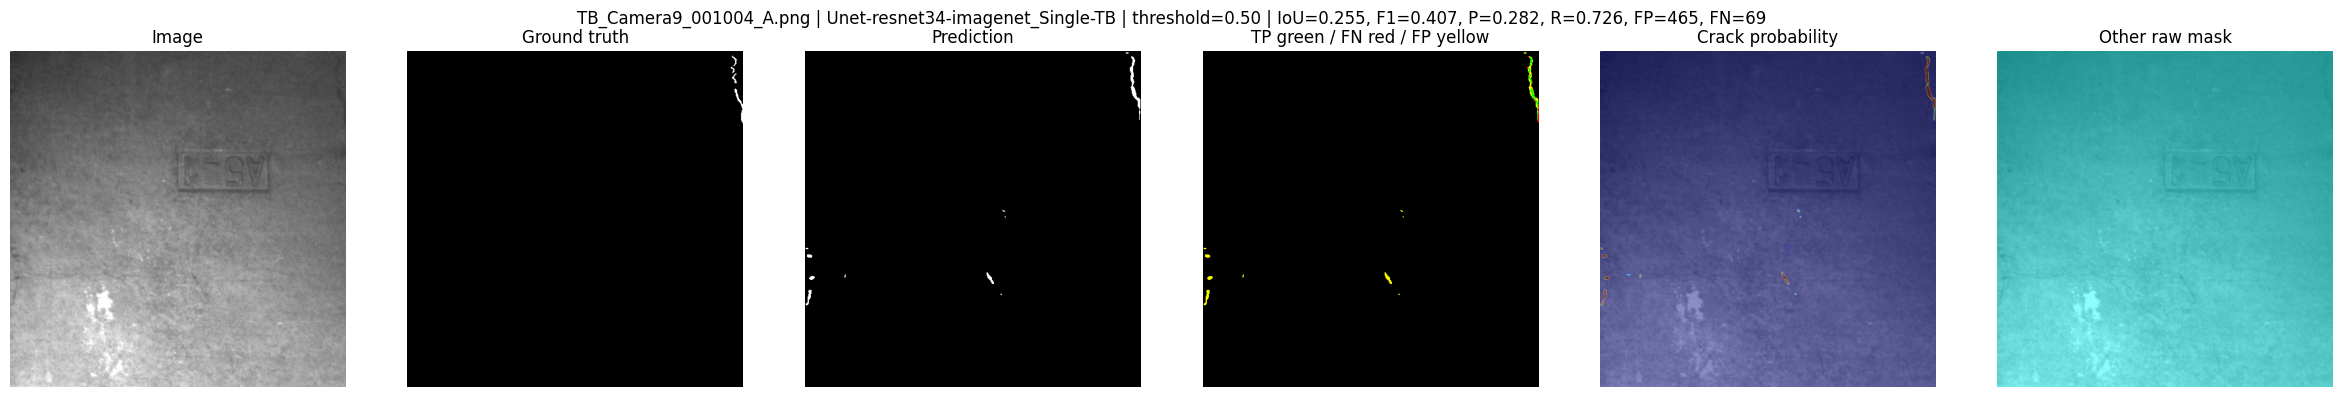

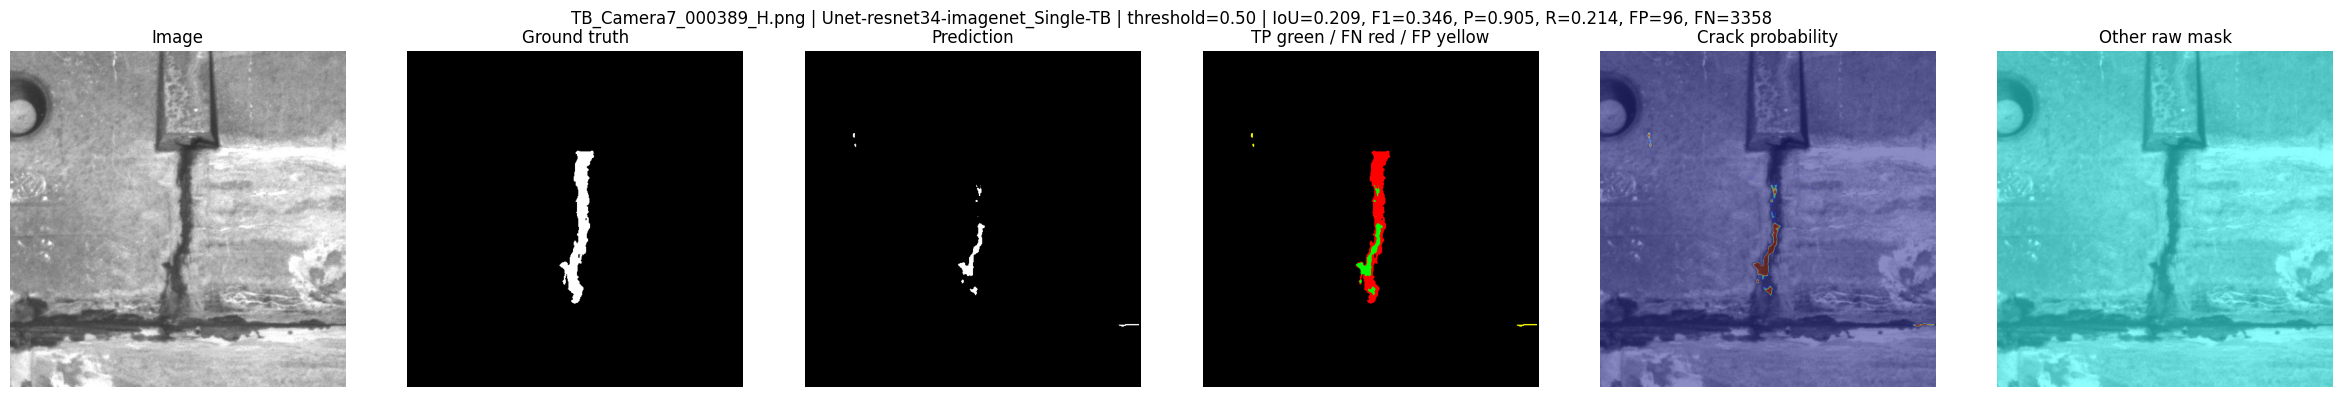

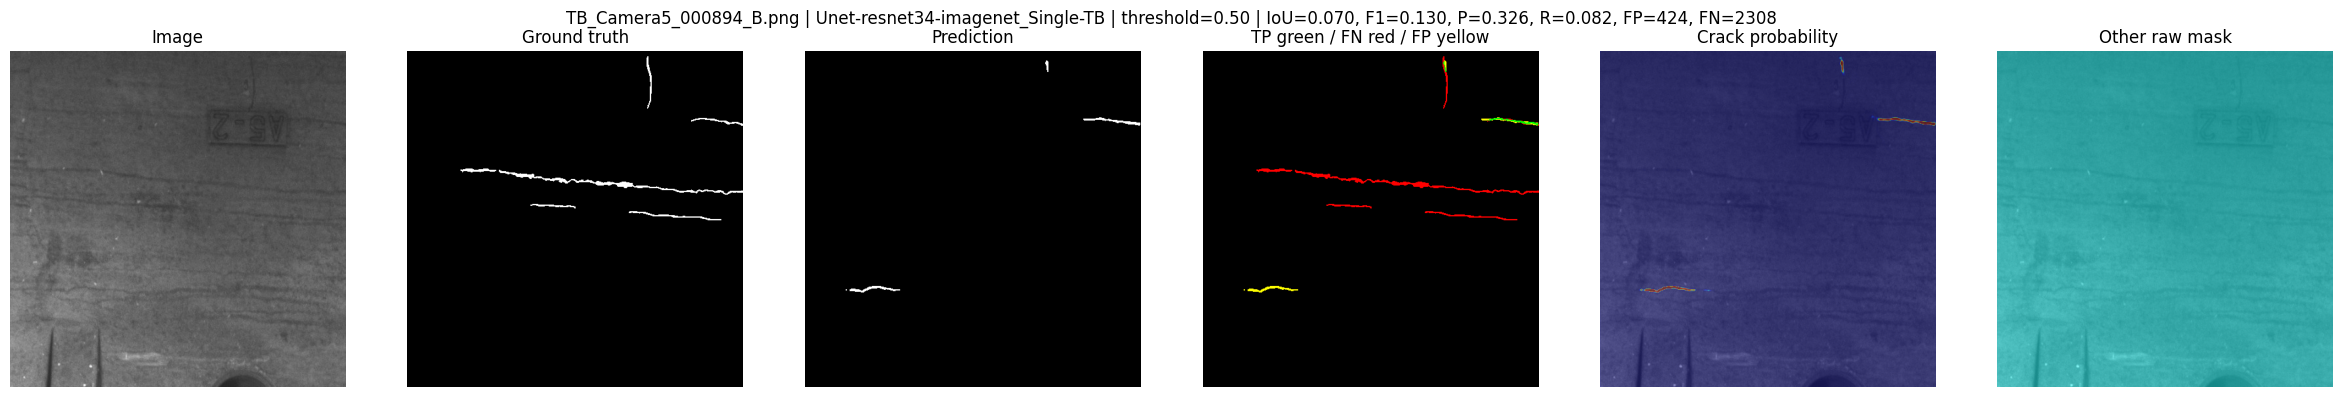

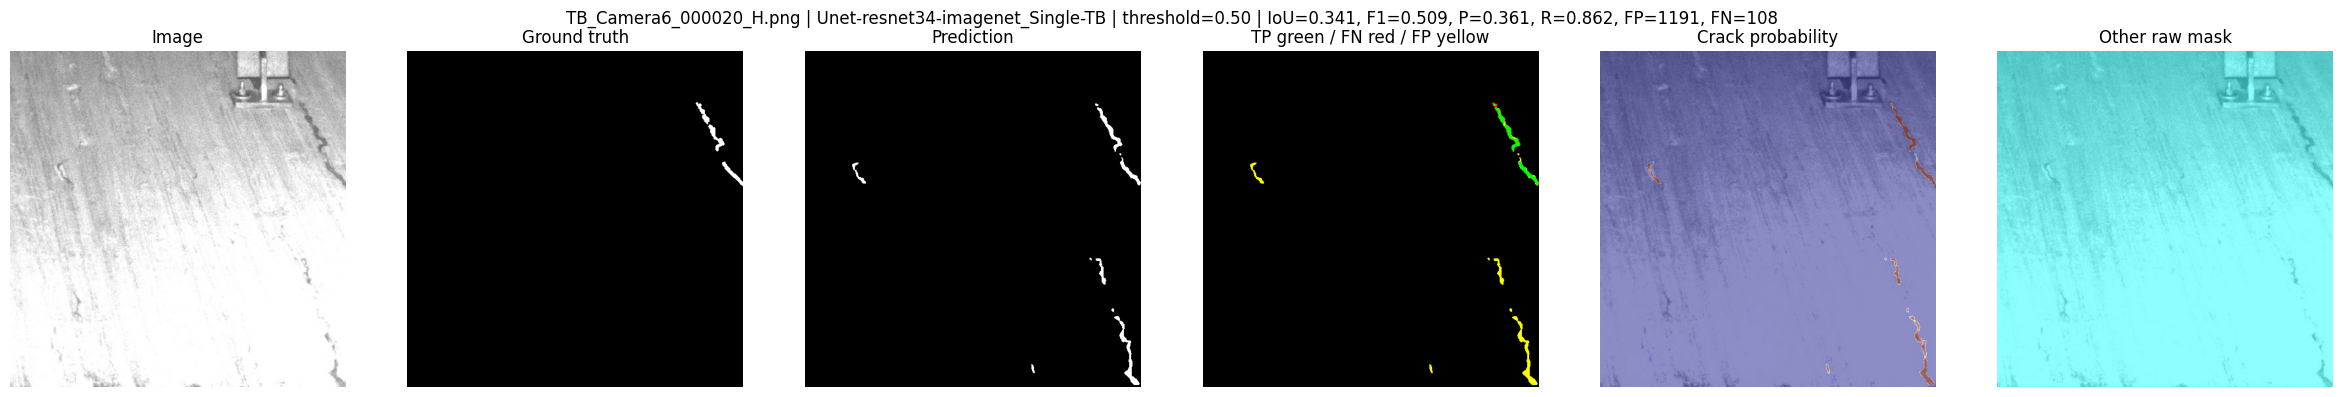

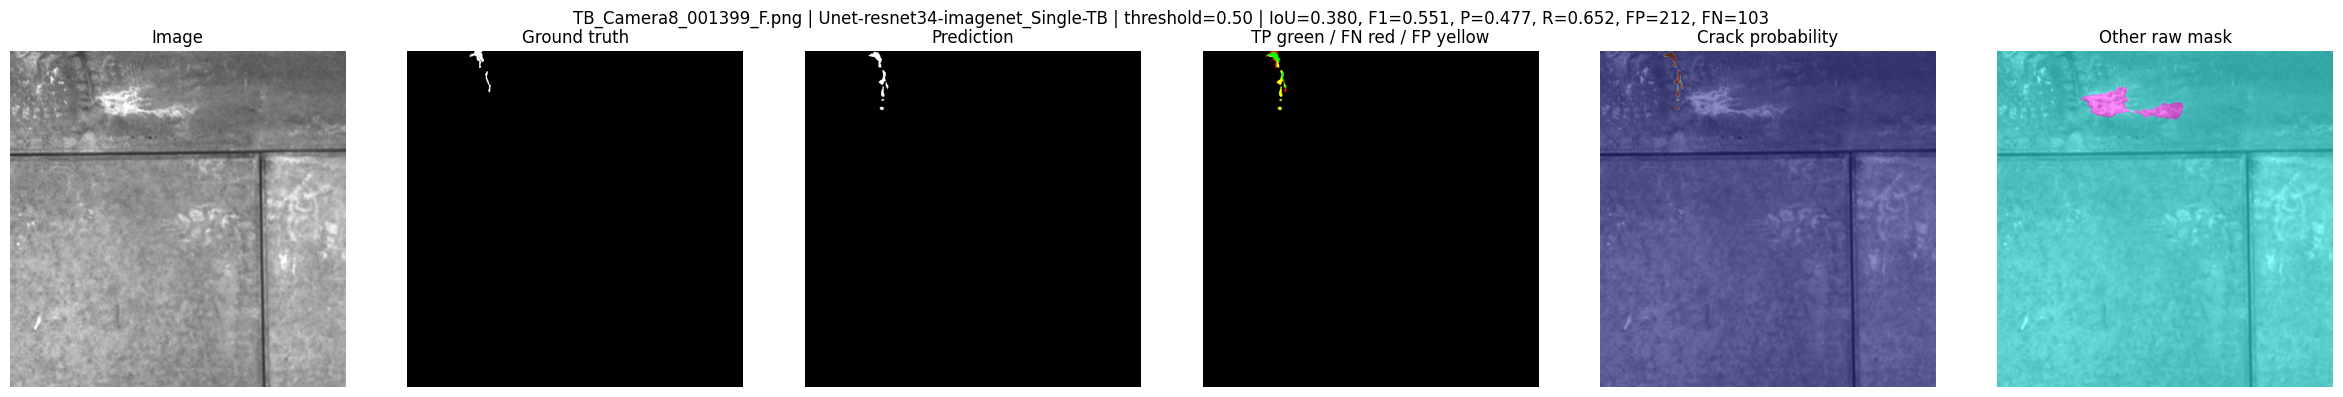

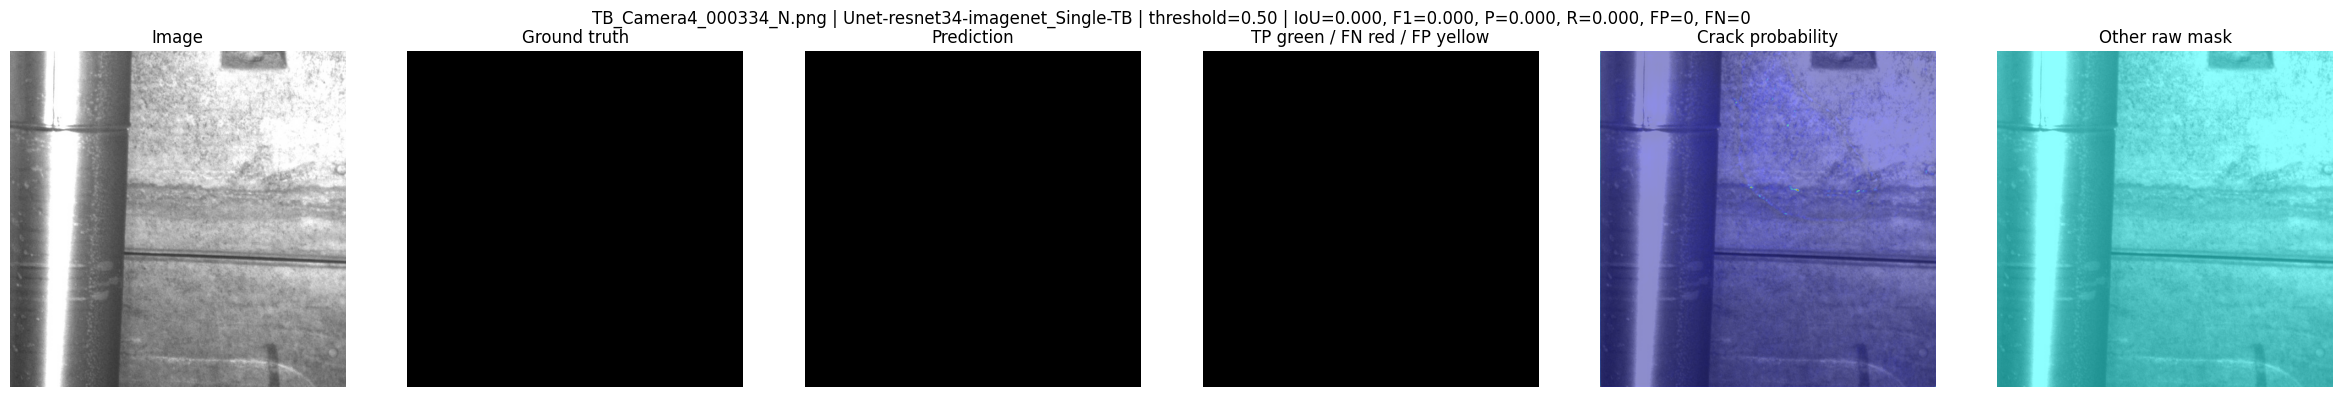

Saved manual review sheet to `/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/manual_review_Unet-resnet34-imagenet_Single-TB_thr0p5.csv`

,model_name,image_name,image_abs_path,threshold,gt_pixels,pred_pixels,tp_pixels,fp_pixels,fn_pixels,iou,f1,precision,recall,panel_path,human_failure_type,notes
0,Unet-resnet34-imagenet_Single-TB,TB_Camera4_001493_I.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera4_001493_I.png,0.5,609,667,339,328,270,0.361793,0.531348,0.508246,0.556650,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/manual_review_panels/Unet-resnet34-imagenet_Single-TB/TB_Camera4_001493_I_png_thr0p5.png,,
1,Unet-resnet34-imagenet_Single-TB,TB_Camera4_000034_L.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera4_000034_L.png,0.5,11756,11300,9455,1845,2301,0.695169,0.820177,0.836726,0.804270,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/manual_review_panels/Unet-resnet34-imagenet_Single-TB/TB_Camera4_000034_L_png_thr0p5.png,,
2,Unet-resnet34-imagenet_Single-TB,TB_Camera5_000894_E.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera5_000894_E.png,0.5,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/manual_review_panels/Unet-resnet34-imagenet_Single-TB/TB_Camera5_000894_E_png_thr0p5.png,,
3,Unet-resnet34-imagenet_Single-TB,TB_Camera7_000012_E.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera7_000012_E.png,0.5,0,17,0,17,0,0.000000,0.000000,0.000000,0.000000,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/manual_review_panels/Unet-resnet34-imagenet_Single-TB/TB_Camera7_000012_E_png_thr0p5.png,,
4,Unet-resnet34-imagenet_Single-TB,TB_Camera9_001004_A.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera9_001004_A.png,0.5,252,648,183,465,69,0.255230,0.406667,0.282407,0.726190,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/manual_review_panels/Unet-resnet34-imagenet_Single-TB/TB_Camera9_001004_A_png_thr0p5.png,,
5,Unet-resnet34-imagenet_Single-TB,TB_Camera7_000389_H.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera7_000389_H.png,0.5,4271,1009,913,96,3358,0.209068,0.345833,0.904856,0.213767,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/manual_review_panels/Unet-resnet34-imagenet_Single-TB/TB_Camera7_000389_H_png_thr0p5.png,,
6,Unet-resnet34-imagenet_Single-TB,TB_Camera5_000894_B.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera5_000894_B.png,0.5,2513,629,205,424,2308,0.069799,0.130490,0.325914,0.081576,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/manual_review_panels/Unet-resnet34-imagenet_Single-TB/TB_Camera5_000894_B_png_thr0p5.png,,
7,Unet-resnet34-imagenet_Single-TB,TB_Camera6_000020_H.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera6_000020_H.png,0.5,780,1863,672,1191,108,0.340944,0.508513,0.360709,0.861538,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/manual_review_panels/Unet-resnet34-imagenet_Single-TB/TB_Camera6_000020_H_png_thr0p5.png,,
8,Unet-resnet34-imagenet_Single-TB,TB_Camera8_001399_F.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera8_001399_F.png,0.5,296,405,193,212,103,0.379921,0.550642,0.476543,0.652027,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/manual_review_panels/Unet-resnet34-imagenet_Single-TB/TB_Camera8_001399_F_png_thr0p5.png,,
9,Unet-resnet34-imagenet_Single-TB,TB_Camera4_000334_N.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera4_000334_N.png,0.5,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/manual_review_panels/Unet-resnet34-imagenet_Single-TB/TB_Camera4_000334_N_png_thr0p5.png,,


In [5]:
all_review_rows = []
review_data_cache = {}

for model_name in MODEL_NAMES:
    model, cfg = load_model(model_name)
    setting = cfg['setting']
    display(Markdown(f'## Reviewing `{model_name}` on `{setting}`'))

    if setting not in review_data_cache:
        review_data_cache[setting] = prepare_review_data(setting)
    test_dl, custom_stats, df_test_ready = review_data_cache[setting]

    available_names = set(df_test_ready['image_name'])
    missing = sorted(set(REVIEW_IMAGE_NAMES) - available_names)
    if missing:
        display(Markdown('**Missing image names:** ' + ', '.join(missing)))

    for image_name in REVIEW_IMAGE_NAMES:
        if image_name not in available_names:
            continue
        row, image_tensor, image_np, target, raw_mask = get_sample_from_test_dl(
            image_name=image_name,
            df_test_ready=df_test_ready,
            test_dl=test_dl,
            custom_stats=custom_stats,
        )
        review_row = make_review_panel(
            model_name=model_name,
            model=model,
            row=row,
            image_tensor=image_tensor,
            image_np=image_np,
            target=target,
            raw_mask=raw_mask,
            threshold=DECISION_THRESHOLD,
            save=True,
            show=True,
        )
        all_review_rows.append(review_row)

review_df = pd.DataFrame(all_review_rows)
review_csv_path = OUTPUT_DIR / f"manual_review_{safe_name('_'.join(MODEL_NAMES))}_thr{str(DECISION_THRESHOLD).replace('.', 'p')}.csv"
review_df.to_csv(review_csv_path, index=False)

display(Markdown(f'Saved manual review sheet to `{review_csv_path}`'))
display(review_df)


## 5. Optional: Compare Multiple Models on One Image

If `MODEL_NAMES` contains more than one model, this compact view helps compare predictions for the same image.


In [6]:
def compare_models_on_image(image_name, model_names=MODEL_NAMES, threshold=DECISION_THRESHOLD):
    loaded = []
    base = None
    data_cache = {}

    for model_name in model_names:
        model, cfg = load_model(model_name)
        setting = cfg['setting']
        if setting not in data_cache:
            data_cache[setting] = prepare_review_data(setting)
        test_dl, custom_stats, df_test_ready = data_cache[setting]

        try:
            row, image_tensor, image_np, target, raw_mask = get_sample_from_test_dl(
                image_name=image_name,
                df_test_ready=df_test_ready,
                test_dl=test_dl,
                custom_stats=custom_stats,
            )
        except ValueError:
            print(f'{image_name} not found for {model_name}')
            continue

        prob, pred = predict_tensor(model, image_tensor, threshold=threshold)
        metrics = compute_metrics(pred, target)
        loaded.append((model_name, pred, prob, metrics))
        if base is None:
            base = (image_np, target)

    if not loaded:
        return

    image_np, target = base
    fig, ax = plt.subplots(len(loaded), 4, figsize=(16, 4 * len(loaded)))
    if len(loaded) == 1:
        ax = np.expand_dims(ax, axis=0)
    for r, (model_name, pred, prob, metrics) in enumerate(loaded):
        ax[r, 0].imshow(image_np); ax[r, 0].set_title(f'{image_name}')
        ax[r, 1].imshow(target, cmap='gray'); ax[r, 1].set_title('GT')
        ax[r, 2].imshow(pred, cmap='gray'); ax[r, 2].set_title(
            f'{model_name}\nIoU={metrics["iou"]:.3f}, F1={metrics["f1"]:.3f}'
        )
        ax[r, 3].imshow(make_error_rgb(pred, target)); ax[r, 3].set_title('TP/FN/FP')
        for c in range(4):
            ax[r, c].axis('off')
    plt.tight_layout()
    plt.show()

# Example:
# compare_models_on_image('TB_Camera4_001493_I.png')
